In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error
import tensorflow as tf
import random
import keras

In [2]:
import sys
import os
sys.path.append(os.path.abspath("../../"))
from LSTM.preprocessing import parse_start_time, convert_to_datetime, create_sequences, prepare_sequences_from_cycles


In [3]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

In [4]:
discharge_dataset = pd.read_csv("../../../dataset/processed/preprocessed_discharge_data.csv")

In [5]:
discharge_data = discharge_dataset[discharge_dataset["battery_id"] == "B0005"].copy()

## Extract features

### Take 175 timesteps in each of the cycle, and then concatenate 168 cycles, each cycle have 5 features

In [6]:
columns = ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load']
data_path = "../../../dataset/processed/data"

X = prepare_sequences_from_cycles(discharge_data, data_path, columns)

100%|██████████| 168/168 [00:00<00:00, 231.90it/s]


In [7]:
# (cycles, each rows in a cycle, features)
X.shape

(168, 175, 5)

In [8]:
timesteps = X.shape[1]
features = X.shape[2]
latent_dim = 12

In [9]:
from keras.api.models import Model, Sequential
from keras.api.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from keras.api.utils import plot_model
from keras.api.optimizers import Adam
from keras.api.callbacks import EarlyStopping, ModelCheckpoint
from keras.api.metrics import RootMeanSquaredError

input_layer = Input(shape=(timesteps, features))
encoded = LSTM(64, activation='tanh', return_sequences=True)(input_layer)
encoded = LSTM(32, activation='tanh', return_sequences=True)(encoded)
encoded = LSTM(latent_dim, activation='tanh', return_sequences=False)(encoded)

decoded = RepeatVector(timesteps)(encoded)
decoded = LSTM(32, activation='tanh', return_sequences=True)(decoded)
decoded = LSTM(64, activation='tanh', return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(features, activation='linear'))(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
encoder = Model(inputs=input_layer, outputs=encoded)

autoencoder.compile(loss="mse", optimizer=Adam(), metrics=[RootMeanSquaredError()])

In [10]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 175, 5)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 175, 64)        │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 175, 32)        │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 12)             │         2,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 175, 12)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 175, 32)        │         5,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 175, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 175, 5)         │           325 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,413 (247.71 KB)

 Trainable params: 63,413 (247.71 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('autoencoder/best_autoencoder.keras', save_best_only=True)
]

autoencoder.fit(X, X, epochs=100, batch_size=16, validation_split=0.2, callbacks=callbacks, verbose=1)

Epoch 1/100
8/9 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - loss: 0.3086 - root_mean_squared_error: 0.5536

In [ ]:
encoded_features = encoder.predict(X)

5/6 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/stepWARNING:tensorflow:5 out of the last 14 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000002337A2FDD00> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step


In [ ]:
encoded_features.shape

(168, 12)

In [ ]:
capacity = discharge_data["Capacity"]

In [ ]:
capacity.shape

(168,)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

capacity_scaler = MinMaxScaler()

capacity = np.array(capacity)

capacity_scaled = capacity_scaler.fit_transform(capacity.reshape(-1, 1))

capacity_scaled = capacity_scaled.flatten()

In [ ]:
combined_features = np.hstack((encoded_features, capacity_scaled.reshape(-1, 1))) # (168, 33)

In [ ]:
# (Cycles, seq_len, features)
combined_features.shape

(168, 13)

In [ ]:
seq_len = 20  # How many past cycles to use for prediction
n_out = 20

X, y = create_sequences(combined_features, seq_len)

In [ ]:
X.shape, y.shape

((148, 20, 13), (148, 13))

In [ ]:
# X_train.shape, y_train.shape, X_val.shape, y_val.shape

# Encoder-Decoder Model for future prediction

In [ ]:
# df_combined = pd.DataFrame(combined_features)

In [ ]:
# X_sequences, y_labels = create_sequence(df_combined, seq_length=15, target=100)

In [ ]:
# print("X_sequences shape:", .shape)  # (128, 20, 33)
# print("y_labels shape:", y_seq.shape) # (128, 20, 33)

In [ ]:
timesteps = X.shape[1]
n_features = X.shape[2]

timesteps, n_features

(20, 13)

In [ ]:
# X_train.shape, y_train.shape

In [ ]:
from keras.api.models import Sequential
from keras.api.layers import LSTM, RepeatVector, TimeDistributed, Dense, InputLayer, Dropout, Masking
from keras.api.optimizers import Adam
from keras.api.regularizers import l2

LEARNING_RATE = 0.0007
REGULARIZATION = 0.0002
NUM_EPOCHS = 200
BATCH_SIZE = 64
EARLY_STOPPING=25
STEP_LR = LEARNING_RATE/100

model = Sequential()

opt = Adam(learning_rate=LEARNING_RATE)

model = Sequential()
model.add(Masking(input_shape=(timesteps, n_features)))

model.add(LSTM(256, activation='selu',return_sequences=True,kernel_regularizer=l2(REGULARIZATION)))
model.add(LSTM(256, activation='selu',return_sequences=True,kernel_regularizer=l2(REGULARIZATION)))

model.add(LSTM(128, activation='selu',return_sequences=True,kernel_regularizer=l2(REGULARIZATION)))
model.add(LSTM(128, activation='selu',return_sequences=True,kernel_regularizer=l2(REGULARIZATION)))

model.add(LSTM(64, activation='selu',return_sequences=True,kernel_regularizer=l2(REGULARIZATION)))
model.add(LSTM(64, activation='selu',return_sequences=False,kernel_regularizer=l2(REGULARIZATION)))
model.add(Dense(64, activation='selu', kernel_regularizer=l2(REGULARIZATION)))
model.add(Dense(64, activation='selu', kernel_regularizer=l2(REGULARIZATION)))
model.add(Dense(32, activation='selu', kernel_regularizer=l2(REGULARIZATION)))
model.add(Dense(32, activation='selu', kernel_regularizer=l2(REGULARIZATION)))
model.add(Dense(1, activation='linear'))
model.summary()

model.compile(optimizer=opt, loss='huber', metrics=['mse', 'mae', 'mape', RootMeanSquaredError(name='rmse')])

c:\Users\HLC\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\masking.py:47: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_1 (Masking)             │ (None, 20, 13)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 20, 256)        │       276,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 20, 256)        │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 20, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 20, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_20 (LSTM)                  │ (None, 20, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,224,417 (4.67 MB)

 Trainable params: 1,224,417 (4.67 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking_1 (Masking)             │ (None, 20, 13)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 20, 256)        │       276,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 20, 256)        │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 20, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 20, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_20 (LSTM)                  │ (None, 20, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,224,417 (4.67 MB)

 Trainable params: 1,224,417 (4.67 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras.api.optimizers import Adam
from keras.api.callbacks import EarlyStopping, ModelCheckpoint
from keras.api.metrics import RootMeanSquaredError
from keras.api.regularizers import L2

# Callback to stop training when validation loss stops improving
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

cp = ModelCheckpoint('models/model.keras', save_best_only=True, monitor='val_loss')

In [ ]:
model.fit(X, y, epochs=NUM_EPOCHS, callbacks=[es, cp])

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - loss: 1.0111 - mae: 1.1317 - mape: 1128029.8750 - mse: 1.8998 - rmse: 1.3647
Epoch 2/200
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.4873 - mae: 0.5599 - mape: 539.1826 - mse: 0.3928 - rmse: 0.6267

c:\Users\HLC\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\callbacks\early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,mae,mape,mse,rmse
  current = self.get_monitor_value(logs)
c:\Users\HLC\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\callbacks\model_checkpoint.py:206: UserWarning: Can save best model only with val_loss available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.5505 - mae: 0.6152 - mape: 657123.6875 - mse: 0.5504 - rmse: 0.7389
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - loss: 0.4455 - mae: 0.4875 - mape: 72292.1953 - mse: 0.3106 - rmse: 0.5572
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.4332 - mae: 0.4736 - mape: 7265.4033 - mse: 0.2874 - rmse: 0.5361
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - loss: 0.4286 - mae: 0.4553 - mape: 143527.5312 - mse: 0.2803 - rmse: 0.5294
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - loss: 0.4266 - mae: 0.4678 - mape: 65271.4727 - mse: 0.2788 - rmse: 0.5280
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - loss: 0.4239 - mae: 0.4587 - mape: 101275.5312 - mse: 0.2762 - rmse: 0.5255
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.4221 - mae: 0.4587 - mape: 97447.5781 - mse: 0.2754 - rmse: 0.5248 
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.4206 - mae: 0.4609 - mape: 77174.8906 - mse: 0.2757 - rm

In [ ]:
# X_test = X_test.reshape(1, n_in, features) # (1, 20, 33)
# X_test.shape

In [ ]:
initial_input = combined_features[:seq_len] # (20, 33)
X_input = initial_input.reshape(1, seq_len, latent_dim + 1) # first n_in cycles -> (1, 20, 33)

initial_capacity = X_input[0, 0, -1] # discharge capacity of the first cycle
initial_capacity_real = capacity_scaler.inverse_transform([[initial_capacity]])[0, 0]

threshold = capacity[-1]

print(f"Initial capacity: {initial_capacity_real} Ah")

print (f"Threshold voltage: {threshold} Ah")

Initial capacity: 1.8564874208181568 Ah
Threshold voltage: 1.3250793286429356 Ah


In [ ]:
predicted_capacities = []
current_input = X_input.copy()
i = 0

y_pred = model.predict(current_input, verbose=0)

print(y_pred.shape)

while i < 300:
    y_pred = model.predict(current_input, verbose=0)

    capacity_pred = y_pred[0, -1]

    capacity_pred_real = capacity_scaler.inverse_transform([[capacity_pred]])[0, 0]

    predicted_capacities.append(capacity_pred_real)
    print(f"Predicted capacity for cycle {i + seq_len + 1}: {capacity_pred_real}")

    if capacity_pred_real <= threshold:
        print(f"Predicted capacity for last cycle {i + seq_len + 1}: {capacity_pred_real}")
        break

    next_step = np.zeros((1, 1, latent_dim + 1))
    next_step[0, 0, :] = y_pred[0, :]

    current_input = np.concatenate([current_input[:, 1:, :], next_step], axis=1)
    i += 1

(1, 1)
Predicted capacity for cycle 21: 1.3059569879478636
Predicted capacity for last cycle 21: 1.3059569879478636


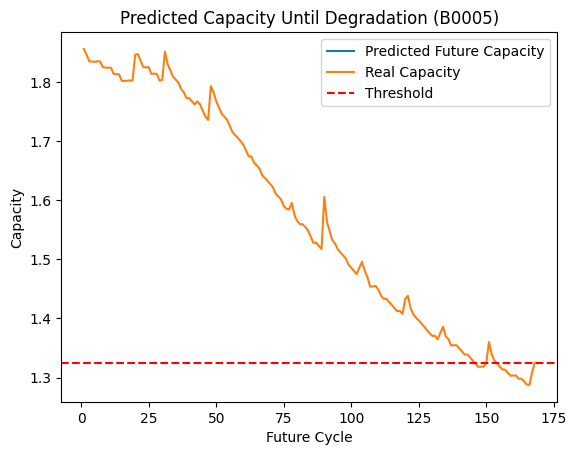

In [ ]:
import matplotlib.pyplot as plt

cycles = list(range(seq_len, seq_len + len(predicted_capacities)))

plt.plot(cycles, predicted_capacities, label="Predicted Future Capacity")
plt.plot(discharge_data["cycle_number"], discharge_data["Capacity"], label="Real Capacity")
plt.axhline(threshold, color='r', linestyle='--', label="Threshold")
plt.xlabel("Future Cycle")
plt.ylabel("Capacity")
plt.legend()
plt.title("Predicted Capacity Until Degradation (B0005)")
plt.show()

In [ ]:
true_capacities = discharge_data["Capacity"].values[seq_len:]

predicted_capacities = predicted_capacities[:len(true_capacities)]

len(true_capacities), len(predicted_capacities)

(148, 1)

## Test on other batteries

In [ ]:
discharge_data_b0006 = discharge_dataset[discharge_dataset["battery_id"] == "B0006"].copy()

In [ ]:
columns = ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load']
data_path = "../../../dataset/processed/data"

X = prepare_sequences_from_cycles(discharge_data_b0006, data_path, columns)

100%|██████████| 168/168 [00:00<00:00, 217.26it/s]


In [ ]:
encoded_features = encoder.predict(X)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


In [ ]:
capacity = discharge_data_b0006["Capacity"]

capacity_scaler = MinMaxScaler()

capacity = np.array(capacity)

capacity_scaled = capacity_scaler.fit_transform(capacity.reshape(-1, 1))

capacity_scaled = capacity_scaled.flatten()

combined_features = np.hstack((encoded_features, capacity_scaled.reshape(-1, 1)))

In [ ]:
X, y = create_sequences(combined_features, seq_len)

initial_input = combined_features[:seq_len] # (20, 33)
X_input = initial_input.reshape(1, seq_len, latent_dim + 1) # first n_in cycles -> (1, 20, 33)

initial_capacity = X_input[0, 0, -1] # discharge capacity of the first cycle
initial_capacity_real = capacity_scaler.inverse_transform([[initial_capacity]])[0, 0]

threshold = capacity[-1]

print(f"Initial capacity: {initial_capacity_real} Ah")

print (f"Threshold capacity: {threshold} Ah")

Initial capacity: 2.035337591005598 Ah
Threshold capacity: 1.1856752327929356 Ah


In [ ]:
predicted_capacities = []
current_input = X_input.copy()
i = 0

while i < 300:
    y_pred = model.predict(current_input, verbose=0)  # shape: (1, 1, 33)

    capacity_pred = y_pred[0, -1]

    capacity_pred_real = capacity_scaler.inverse_transform([[capacity_pred]])[0, 0]

    predicted_capacities.append(capacity_pred_real)
    print(f"Predicted capacity for cycle {i + seq_len + 1}: {capacity_pred_real}")

    if capacity_pred_real <= threshold:
        print(f"Predicted capacity for last cycle {i + seq_len + 1}: {capacity_pred_real}")
        break

    next_step = np.zeros((1, 1, latent_dim + 1))
    next_step[0, 0, :] = y_pred[0, :]

    current_input = np.concatenate([current_input[:, 1:, :], next_step], axis=1)
    i += 1

Predicted capacity for cycle 21: 1.1874772270802514
Predicted capacity for cycle 22: 1.186773753345723
Predicted capacity for cycle 23: 1.1858518598470713
Predicted capacity for cycle 24: 1.1850030137569048
Predicted capacity for last cycle 24: 1.1850030137569048


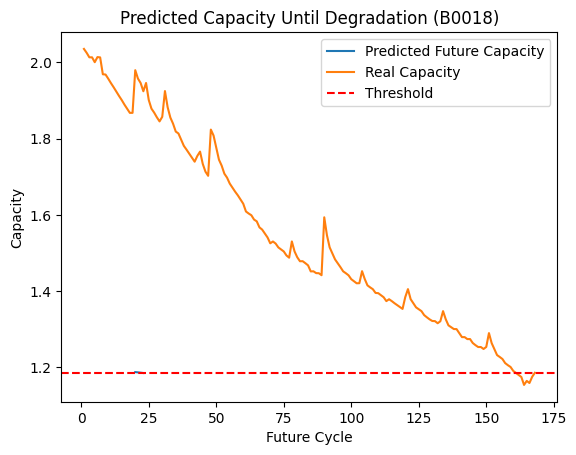

In [ ]:
import matplotlib.pyplot as plt

cycles = list(range(seq_len, seq_len + len(predicted_capacities)))

plt.plot(cycles, predicted_capacities, label="Predicted Future Capacity")
plt.plot(discharge_data_b0006["cycle_number"], discharge_data_b0006["Capacity"], label="Real Capacity")
plt.axhline(threshold, color='r', linestyle='--', label="Threshold")
plt.xlabel("Future Cycle")
plt.ylabel("Capacity")
plt.legend()
plt.title("Predicted Capacity Until Degradation (B0018)")
plt.show()

## Battery from other batch with different temperature (B0029 - 43C)

In [ ]:
discharge_data_b0029 = discharge_dataset[discharge_dataset["battery_id"] == "B0018"].copy()

In [ ]:
columns = ['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load']
data_path = "../../dataset/processed/data"

X = prepare_sequences_from_cycles(discharge_data_b0029, data_path, columns)

encoded_features = encoder.predict(X)

100%|██████████| 132/132 [00:00<00:00, 238.13it/s]


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [ ]:
capacity = discharge_data_b0029["Capacity"]

capacity_scaler = MinMaxScaler()

capacity = np.array(capacity)

capacity_scaled = capacity_scaler.fit_transform(capacity.reshape(-1, 1))

capacity_scaled = capacity_scaled.flatten()

combined_features = np.hstack((encoded_features, capacity_scaled.reshape(-1, 1)))

In [ ]:
X, y = create_sequences(combined_features, seq_len)

initial_input = combined_features[:seq_len] # (20, 33)
X_input = initial_input.reshape(1, seq_len, latent_dim + 1) # first n_in cycles -> (1, 20, 33)

initial_capacity = X_input[0, 0, -1] # discharge capacity of the first cycle
initial_capacity_real = capacity_scaler.inverse_transform([[initial_capacity]])[0, 0]

threshold = capacity[-1]

print(f"Initial capacity: {initial_capacity_real} Ah")

print (f"Threshold capacity: {threshold} Ah")

Initial capacity: 1.8550045207910817 Ah
Threshold capacity: 1.341051440640485 Ah


In [ ]:
predicted_capacities = []
current_input = X_input.copy()
i = 0

while i < 300:
    y_pred = model.predict(current_input, verbose=0)  # shape: (1, 1, 33)

    capacity_pred = y_pred[0, -1]

    capacity_pred_real = capacity_scaler.inverse_transform([[capacity_pred]])[0, 0]

    predicted_capacities.append(capacity_pred_real)
    print(f"Predicted capacity for cycle {i + seq_len + 1}: {capacity_pred_real}")

    if capacity_pred_real <= threshold:
        print(f"Predicted capacity for last cycle {i + seq_len + 1}: {capacity_pred_real}")
        break

    next_step = np.zeros((1, 1, latent_dim + 1))
    next_step[0, 0, :] = y_pred[0, :]

    current_input = np.concatenate([current_input[:, 1:, :], next_step], axis=1)
    i += 1

Predicted capacity for cycle 21: 1.2806833478892665
Predicted capacity for last cycle 21: 1.2806833478892665


In [ ]:
import matplotlib.pyplot as plt


cycles = list(range(seq_len, seq_len + len(predicted_capacities)))

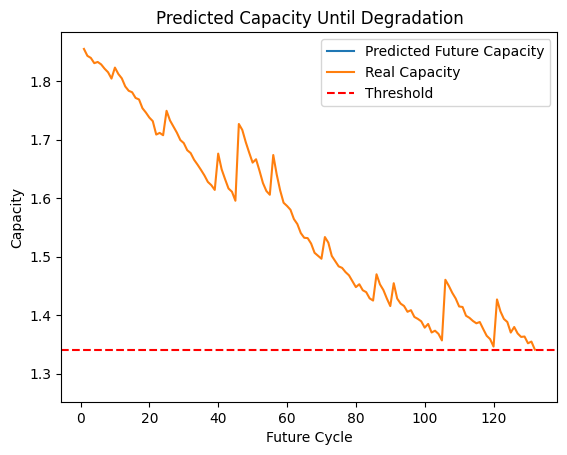

In [ ]:
import matplotlib.pyplot as plt

plt.plot(cycles, predicted_capacities, label="Predicted Future Capacity")
plt.plot(discharge_data_b0029["cycle_number"], discharge_data_b0029["Capacity"], label="Real Capacity")
plt.axhline(threshold, color='r', linestyle='--', label="Threshold")
plt.xlabel("Future Cycle")
plt.ylabel("Capacity")
plt.legend()
plt.title("Predicted Capacity Until Degradation")
plt.show()